In [52]:
import numpy as np
import tensorflow as tf 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [53]:
model = tf.keras.models.load_model('Plant_disease_model.keras')

In [54]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

### Visualizaing Single image of test set

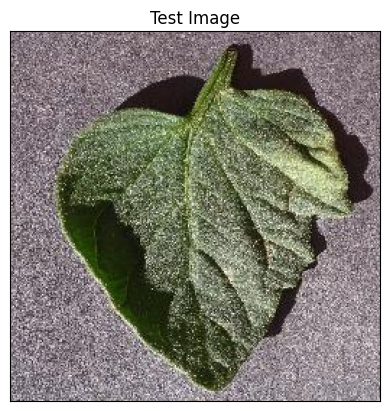

In [55]:
import cv2 
image_path = 'test\\test\\TomatoHealthy1.JPG'
# Read Image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

# Display Image
plt.imshow(img)
plt.title('Test Image')
plt.xticks([])
plt.yticks([])
plt.show()

### Testing Model

In [56]:
image = tf.keras.preprocessing.image.load_img(image_path, target_size=(128, 128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) # Convert single image to a batch.

In [57]:
print(input_arr.shape)

(1, 128, 128, 3)


In [58]:
prediction  = model.predict(input_arr)
print(prediction)

1/1 [==============================] - 0s 255ms/step
[[1.04875437e-16 5.40764983e-19 3.28460228e-18 5.89981741e-15
  8.23095068e-17 2.15983322e-15 7.94553572e-20 3.14812378e-19
  8.10524152e-21 3.62734208e-18 4.02583973e-17 1.13165355e-23
  4.36486956e-20 5.79555470e-23 6.49666260e-22 2.77715753e-21
  3.00129173e-19 2.39790069e-19 2.08267955e-20 3.73548313e-18
  4.61257483e-14 7.72877175e-20 1.17983335e-18 1.33819612e-19
  5.76562423e-18 1.26880485e-11 7.63386738e-19 3.55913773e-18
  1.13736042e-18 1.13312344e-21 3.98651686e-14 5.87141894e-14
  4.53799638e-15 1.19097200e-16 7.82666727e-12 1.23637268e-21
  3.38200755e-19 1.00000000e+00]]


In [59]:
prediction.shape

(1, 38)

In [60]:
result = np.argmax(prediction)

In [61]:
result

37

In [62]:
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

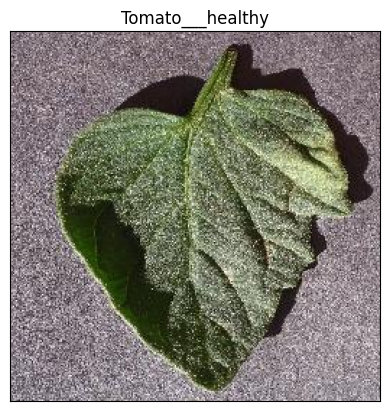

In [63]:
# Display the predicted class

plt.imshow(img)
plt.title(class_name[result])
plt.xticks([])
plt.yticks([])
plt.show()